# Power Station Analysis

This notebook is analyzing the hardware data set in order to use statistically relevant data in other parts of this research

It clusters the data and chooses representative components.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt  # for visualization
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score
from scipy.spatial.distance import cdist
import matplotlib.cm as cm
from sklearn.preprocessing import StandardScaler
#%pip install yellowbrick
#from yellowbrick.cluster import SilhouetteVisualizer
import numpy as np

In [2]:
# read in hardware data to dataframe
hardware_df = pd.read_csv('data/PowerStations_LiFePo4_June29_2026.csv')

In [3]:
#clean data - these columns aren't used in this analysis
hardware_df = hardware_df.drop(columns=['Link','Min PV Voltage','Max PV Voltage','Warranty Years','Lifespan','Notes','Estimated Full Charge Time','Estimated Minimum Grid Charge Efficiency','Passthrough','Retail Price (1/24/2025)','Retail Price (1/30/2025)','Max PV Amps'])

retailPriceColumns = ['Retail Price (3/14/2026)']

#filter out batteries over specified size
#print(hardware_df[hardware_df['Battery Wh'] > 2000])
#hardware_df = hardware_df[hardware_df['Battery Wh'] <= 2000]

hardware_df.head()

,Make,Model,Battery Wh,Max PV Watts,Inverter Watts,Max AC Input Watts,Full Grid Charge Hours,80 Per Grid Charge Hours,Inverter Efficiency,Retail Price (3/14/2026),Cycles,DoD,community API,official API,potential API
0,Jackery,Explorer 300 Plus,288.00,100,300.0,100.0,2.00,NaN,85.0,299,3000,80,True,False,False
1,Jackery,Explorer 600 Plus,632.00,200,800.0,1800.0,1.60,NaN,85.0,429,4000,70,True,False,False
2,Jackery,Explorer 700 Plus,680.96,600,1000.0,NaN,1.75,NaN,85.0,599,4000,70,True,False,False
3,Jackery,Explorer 1000 Plus,1264.64,800,2000.0,NaN,1.70,NaN,85.0,599,4000,70,True,False,False
4,Jackery,Explorer 2000 Plus,2042.80,1400,3000.0,NaN,2.00,NaN,85.0,1099,4000,70,True,False,False


In [4]:
#get average retail prices
hardware_df['avg retail price']= hardware_df[retailPriceColumns].mean(axis=1)
hardware_df.head()

,Make,Model,Battery Wh,Max PV Watts,Inverter Watts,Max AC Input Watts,Full Grid Charge Hours,80 Per Grid Charge Hours,Inverter Efficiency,Retail Price (3/14/2026),Cycles,DoD,community API,official API,potential API,avg retail price
0,Jackery,Explorer 300 Plus,288.00,100,300.0,100.0,2.00,NaN,85.0,299,3000,80,True,False,False,299.0
1,Jackery,Explorer 600 Plus,632.00,200,800.0,1800.0,1.60,NaN,85.0,429,4000,70,True,False,False,429.0
2,Jackery,Explorer 700 Plus,680.96,600,1000.0,NaN,1.75,NaN,85.0,599,4000,70,True,False,False,599.0
3,Jackery,Explorer 1000 Plus,1264.64,800,2000.0,NaN,1.70,NaN,85.0,599,4000,70,True,False,False,599.0
4,Jackery,Explorer 2000 Plus,2042.80,1400,3000.0,NaN,2.00,NaN,85.0,1099,4000,70,True,False,False,1099.0


In [5]:
#display(hardware_df.tail())

#get average charge time percent for 80% relative to a 100% charge
hardware_df['charge ratio']= hardware_df['80 Per Grid Charge Hours']/hardware_df['Full Grid Charge Hours']

#display(hardware_df[~hardware_df['charge ratio'].isnull()]['charge ratio'])
#get the average ratio of 80% to 100% 
eightyCT = round(hardware_df[~hardware_df['charge ratio'].isnull()]['charge ratio'].mean()*100,2)*.01
print(str(eightyCT*100) + '% of the full charge time is spent charging from 0-80%.')
# #display(hardware_df.tail())

#update full charge column
hardware_df['Full Grid Charge Hours'].loc[hardware_df['Full Grid Charge Hours'].isnull()] = hardware_df['80 Per Grid Charge Hours'].loc[hardware_df['Full Grid Charge Hours'].isnull()] / eightyCT

#update 80% charge column
hardware_df['80 Per Grid Charge Hours'].loc[hardware_df['80 Per Grid Charge Hours'].isnull()] = hardware_df['Full Grid Charge Hours'].loc[hardware_df['80 Per Grid Charge Hours'].isnull()] * eightyCT

display(hardware_df.tail())

61.19% of the full charge time is spent charging from 0-80%.


C:\Users\alexn\AppData\Local\Temp\ipykernel_7644\230361453.py:13: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  hardware_df['Full Grid Charge Hours'].loc[hardware_df['Full Grid Charge Hours'].isnull()] = hardware_df['80 Per Grid Charge Hours

,Make,Model,Battery Wh,Max PV Watts,Inverter Watts,Max AC Input Watts,Full Grid Charge Hours,80 Per Grid Charge Hours,Inverter Efficiency,Retail Price (3/14/2026),Cycles,DoD,community API,official API,potential API,avg retail price,charge ratio
61,OUKITEL,P1201,960.0,500,1200.0,700.0,2.451381,1.5,NaN,799,3500,80,False,False,False,799.0,NaN
62,OUKITEL,P2001,2000.0,500,2000.0,1100.0,2.941657,1.8,NaN,709,3500,80,False,False,False,709.0,NaN
63,OUKITEL,BP2000,2048.0,1000,2200.0,1800.0,2.451381,1.5,NaN,899,3500,80,False,False,False,899.0,NaN
64,OUKITEL,BP2000,2048.0,1000,2200.0,1800.0,2.451381,1.5,NaN,899,3500,80,False,False,False,899.0,NaN
65,Zendure,SuperBase Pro Power Station 1500,1440.0,600,2000.0,1800.0,2.000000,1.0,NaN,1699,3000,80,False,False,True,1699.0,0.5


In [6]:
#if inverter efficiency data isn't available use minimum value
defaultInverterEfficiency = min(hardware_df['Inverter Efficiency'])

hardware_df['Inverter Efficiency'] = hardware_df['Inverter Efficiency'].fillna(defaultInverterEfficiency)

In [7]:
hardware_df['Battery WhAC']= hardware_df['Battery Wh'] * hardware_df['Inverter Efficiency'] * 0.01

In [8]:
hardware_df['$/WhAC']= hardware_df['avg retail price'] / hardware_df['Battery WhAC']

In [9]:
hardware_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66 entries, 0 to 65
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Make                      66 non-null     object 
 1   Model                     66 non-null     object 
 2   Battery Wh                66 non-null     float64
 3   Max PV Watts              66 non-null     int64  
 4   Inverter Watts            65 non-null     float64
 5   Max AC Input Watts        54 non-null     float64
 6   Full Grid Charge Hours    66 non-null     float64
 7   80 Per Grid Charge Hours  66 non-null     float64
 8   Inverter Efficiency       66 non-null     float64
 9   Retail Price (3/14/2026)  66 non-null     int64  
 10  Cycles                    66 non-null     int64  
 11  DoD                       66 non-null     int64  
 12  community API             66 non-null     bool   
 13  official API              66 non-null     bool   
 14  potential AP

In [13]:
len(hardware_df['Make'].unique())

13

In [10]:
#drop columns with significant missing data or shouldn't be considered in clustering
cleaned_df = hardware_df.drop(columns=['Battery Wh','Inverter Efficiency','Inverter Watts','Cycles','Make','Model','Max AC Input Watts','charge ratio','DoD','Retail Price (3/14/2026)','Full Grid Charge Hours','80 Per Grid Charge Hours'])

In [127]:
cleaned_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66 entries, 0 to 65
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Max PV Watts      66 non-null     int64  
 1   avg retail price  66 non-null     float64
 2   Battery WhAC      66 non-null     float64
 3   $/WhAC            66 non-null     float64
dtypes: float64(3), int64(1)
memory usage: 2.2 KB


In [128]:
cleaned_df = cleaned_df.drop(columns=['avg retail price','Battery WhAC'])
cleaned_df.describe()

,Max PV Watts,$/WhAC
count,66.000000,66.000000
mean,639.393939,0.652197
std,531.488125,0.288373
min,100.000000,0.357197
25%,220.000000,0.455492
50%,500.000000,0.548706
75%,1000.000000,0.776868
max,2400.000000,1.651503


In [129]:
cleaned_df[cleaned_df['$/WhAC']<0.6]

,Max PV Watts,$/WhAC
3,800,0.557238
5,400,0.460333
7,100,0.386029
8,400,0.457942
9,600,0.423943
10,800,0.359222
11,1200,0.367034
12,800,0.361328
13,2400,0.401731
22,500,0.475984


## Scale and Encode

no encoding currently being done

In [130]:
# scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cleaned_df)

In [131]:
X_scaled

array([[-1.0226518 ,  1.98898203],
       [-0.83305905,  0.51152261],
       [-0.07468805,  1.33717631],
       [ 0.30449745, -0.33181572],
       [ 1.44205394, -0.06734046],
       [-0.45387355, -0.6704319 ],
       [-1.0226518 , -0.15213257],
       [-1.0226518 , -0.93007088],
       [-0.45387355, -0.67878632],
       [-0.07468805, -0.79758941],
       [ 0.30449745, -1.02374464],
       [ 1.06286844, -0.99644543],
       [ 0.30449745, -1.01638456],
       [ 3.33798143, -0.87520482],
       [-0.07468805,  1.01731317],
       [-0.92785542,  0.05055961],
       [-0.83305905,  0.89371137],
       [-0.83305905,  0.04730607],
       [-0.83305905,  0.55681427],
       [-0.83305905, -0.03437127],
       [-0.83305905,  3.49187093],
       [-0.83305905,  2.33541211],
       [-0.2642808 , -0.61574336],
       [-0.2642808 , -0.76572051],
       [-0.2642808 , -0.11417124],
       [ 0.1149047 , -0.14550939],
       [ 1.06286844, -0.76424601],
       [ 1.06286844,  0.24620396],
       [ 0.68368294,

## Cluster

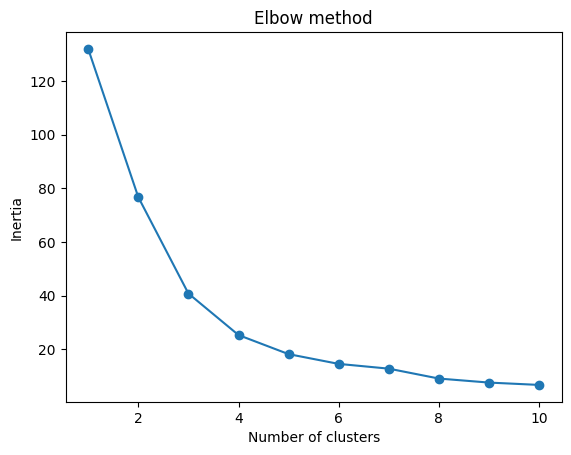

In [132]:
inertias = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.plot(range(1,11), inertias, marker='o')
plt.title('Elbow method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show() 

In [133]:
#get avg silhouette scores
silhouettes = []
for i in range(2,20):
    kmeans = KMeans(n_clusters=i, random_state=10)
    kmeans.fit(X_scaled)
    kmeans.labels_
    score = silhouette_score(X_scaled, kmeans.labels_, metric='euclidean')
    print('For ' + str(i) + ' clusters, the average silhoutte score is ' + str(score))
    silhouettes.append(score)

For 2 clusters, the average silhoutte score is 0.4223233676059731
For 3 clusters, the average silhoutte score is 0.45341582176057615
For 4 clusters, the average silhoutte score is 0.4860155431477584
For 5 clusters, the average silhoutte score is 0.4507494521063626
For 6 clusters, the average silhoutte score is 0.4227474909072516
For 7 clusters, the average silhoutte score is 0.42476125346052634
For 8 clusters, the average silhoutte score is 0.4433563426918118
For 9 clusters, the average silhoutte score is 0.41788879432108733
For 10 clusters, the average silhoutte score is 0.4194725088678819
For 11 clusters, the average silhoutte score is 0.385081932483429
For 12 clusters, the average silhoutte score is 0.40268520046965783
For 13 clusters, the average silhoutte score is 0.39518344020325313
For 14 clusters, the average silhoutte score is 0.41470781233587783
For 15 clusters, the average silhoutte score is 0.41690579796363564
For 16 clusters, the average silhoutte score is 0.37831266151758

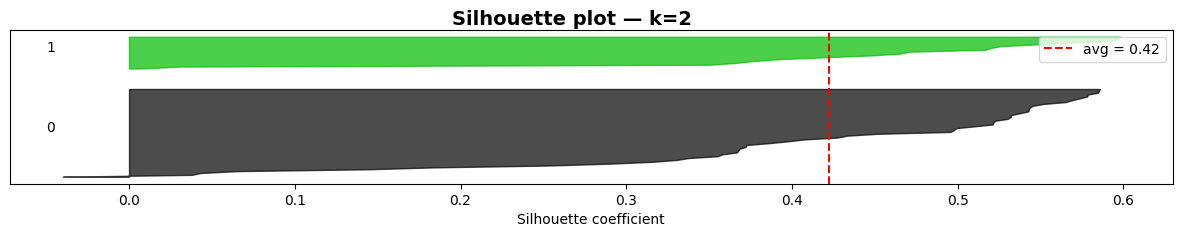

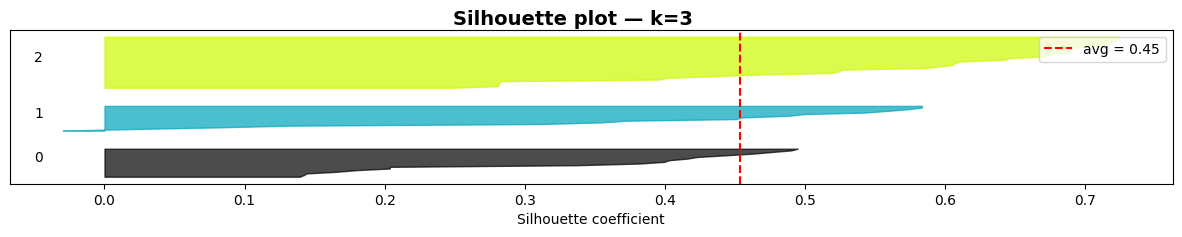

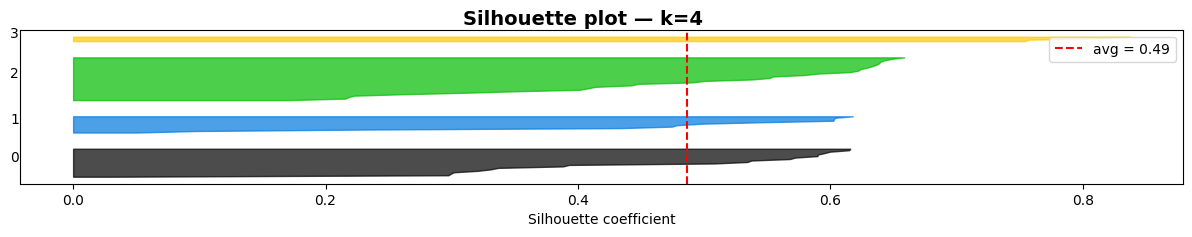

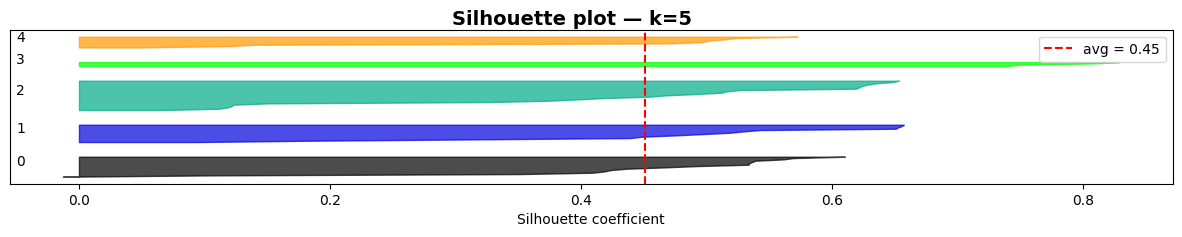

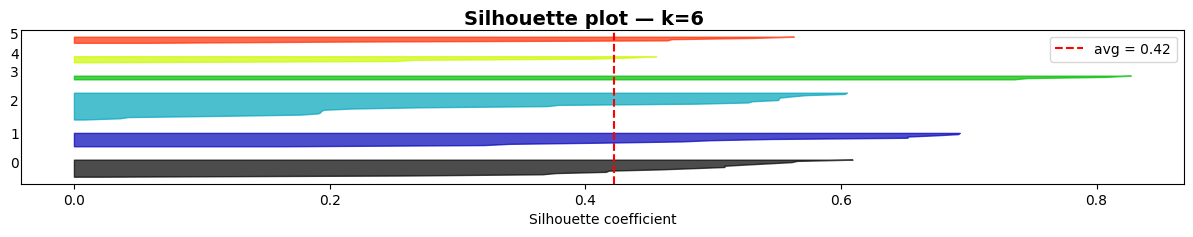

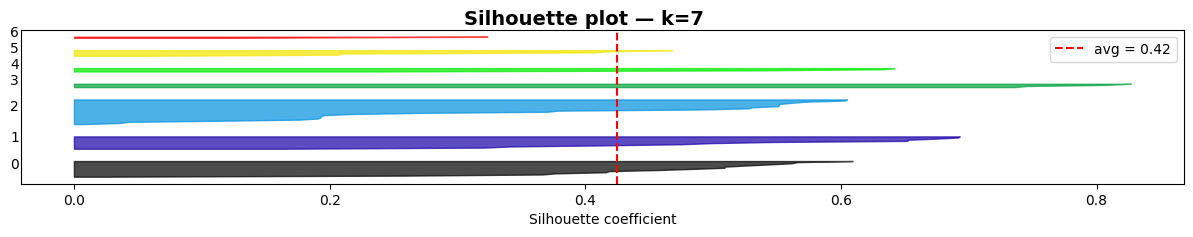

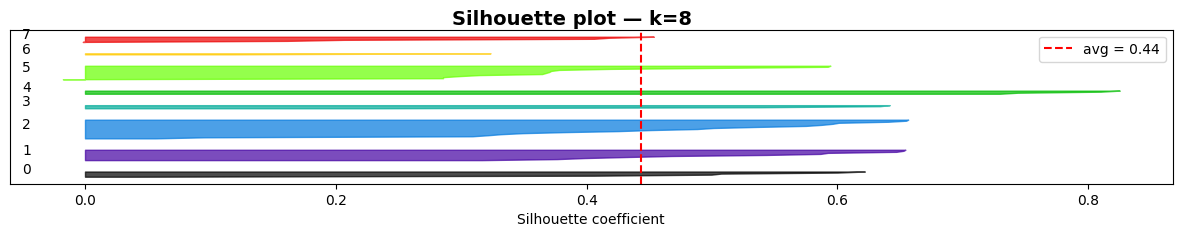

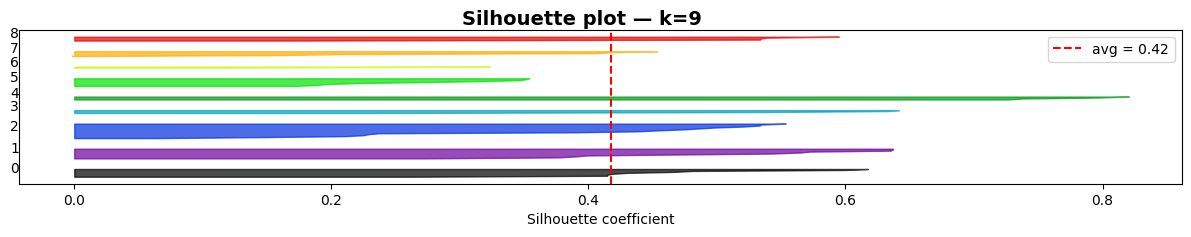

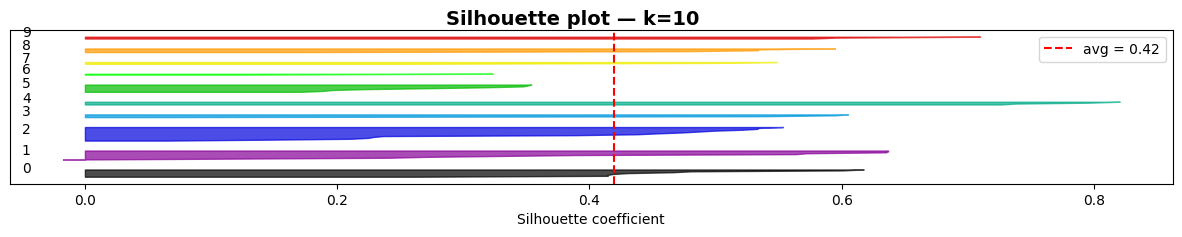

In [134]:
for s in range(2, 11):
    fig, ax1 = plt.subplots(figsize=(15, 2))
    
    kmeans = KMeans(n_clusters=s, random_state=10)
    labels = kmeans.fit_predict(X_scaled)
    avg_score = silhouette_score(X_scaled, labels)
    sample_scores = silhouette_samples(X_scaled, labels)
    
    y_lower = 10
    for i in range(s):
        cluster_scores = sorted(sample_scores[labels == i])
        size = len(cluster_scores)
        y_upper = y_lower + size
        color = cm.nipy_spectral(i / s)
        ax1.fill_betweenx(range(y_lower, y_upper), 0, cluster_scores, color=color, alpha=0.7)
        ax1.text(-0.05, y_lower + size / 2, str(i))
        y_lower = y_upper + 10
    
    ax1.axvline(x=avg_score, color="red", linestyle="--", label=f"avg = {avg_score:.2f}")
    ax1.set_xlabel("Silhouette coefficient")
    ax1.set_yticks([])
    ax1.legend(loc="upper right")
    plt.suptitle(f"Silhouette plot — k={s}", fontsize=14, fontweight="bold")
    plt.show()

In [135]:
# # test
# K_RANGE = range(2, min(12, len(cleaned_df)))

# inertias, silhouettes = [], []

# for k in K_RANGE:
#     km = KMeans(n_clusters=k, random_state=42, n_init=10)
#     labels = km.fit_predict(X_scaled)
#     inertias.append(km.inertia_)
#     silhouettes.append(silhouette_score(X_scaled, labels))

# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# ax1.plot(K_RANGE, inertias, "o-")
# ax1.set_xlabel("k"); ax1.set_ylabel("Inertia")
# ax1.set_title("Elbow method")

# ax2.plot(K_RANGE, silhouettes, "o-", color="tab:orange")
# ax2.set_xlabel("k"); ax2.set_ylabel("Silhouette score")
# ax2.set_title("Silhouette score (higher = better)")

# plt.tight_layout()
# plt.show()

# # Look for the elbow in inertia AND the peak in silhouette
# best_k_silhouette = K_RANGE[np.argmax(silhouettes)]
# print(f"Best k by silhouette: {best_k_silhouette}")

In [136]:
features = list(cleaned_df.columns)
features

['Max PV Watts', '$/WhAC']

In [137]:
for k in [3, 4]:
    km = KMeans(n_clusters=k, random_state=10)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    sizes = pd.Series(labels).value_counts().sort_index().tolist()
    print(f"k={k} | silhouette={score:.4f} | cluster sizes={sizes}")


for k in [3, 4]:
    cleaned_df[f"{k}cluster"] = KMeans(n_clusters=k, random_state=10).fit_predict(X_scaled)
    print(f"\n--- k={k} ---")
    print(cleaned_df.groupby(f"{k}cluster")[features].mean().T.round(1))

k=3 | silhouette=0.4534 | cluster sizes=[18, 16, 32]
k=4 | silhouette=0.4860 | cluster sizes=[20, 12, 30, 4]

--- k=3 ---
3cluster           0      1      2
Max PV Watts  1344.4  284.4  420.3
$/WhAC           0.5    1.1    0.5

--- k=4 ---
4cluster           0      1      2       3
Max PV Watts  1015.0  327.5  312.3  2150.0
$/WhAC           0.5    1.2    0.6     0.4


In [142]:
# kmeans = KMeans(n_clusters=4)
# kmeans.fit(cleaned_df)

# print(kmeans.labels_)

In [140]:
clustered_df = cleaned_df
clustered_df['Make'] =  hardware_df['Make']
clustered_df['Model'] =  hardware_df['Model']
clustered_df['Cost'] =  hardware_df['avg retail price']
clustered_df['WhAC'] = hardware_df['Battery WhAC']

#clustered_df['labels'] = kmeans.labels_

clustered_df.head()

,Max PV Watts,$/WhAC,3cluster,4cluster,Make,Model,Cost,WhAC,labels
0,100,1.221405,1,1,Jackery,Explorer 300 Plus,299.0,244.800,3
1,200,0.798585,1,2,Jackery,Explorer 600 Plus,429.0,537.200,1
2,600,1.034871,1,1,Jackery,Explorer 700 Plus,599.0,578.816,9
3,800,0.557238,2,0,Jackery,Explorer 1000 Plus,599.0,1074.944,5
4,1400,0.632926,0,0,Jackery,Explorer 2000 Plus,1099.0,1736.380,8


In [143]:
clustered_df[clustered_df['4cluster']==0]

,Max PV Watts,$/WhAC,3cluster,4cluster,Make,Model,Cost,WhAC,labels
3,800,0.557238,2,0,Jackery,Explorer 1000 Plus,599.0,1074.944,5
4,1400,0.632926,0,0,Jackery,Explorer 2000 Plus,1099.0,1736.380,8
10,800,0.359222,2,0,Pecron,E1500LFP Expandable,469.0,1305.600,5
11,1200,0.367034,0,0,Pecron,E2000LFP Expandable,599.0,1632.000,0
12,800,0.361328,2,0,Pecron,E2400LFP,629.0,1740.800,5
25,700,0.610556,2,0,Bluetti,AC200P,1099.0,1800.000,5
26,1200,0.433485,0,0,Bluetti,AC200L,799.0,1843.200,0
27,1200,0.722656,0,0,Bluetti,AC240,999.0,1382.400,8
28,1000,0.428257,0,0,Bluetti,Elite 200V2,799.0,1865.700,0
30,1000,0.813260,0,0,EcoFlow,DELTA 2 Max,1499.0,1843.200,8


In [144]:
clustered_df[clustered_df['4cluster']==1]

,Max PV Watts,$/WhAC,3cluster,4cluster,Make,Model,Cost,WhAC,labels
0,100,1.221405,1,1,Jackery,Explorer 300 Plus,299.0,244.800,3
2,600,1.034871,1,1,Jackery,Explorer 700 Plus,599.0,578.816,9
14,600,0.943333,1,1,Lion Energy,Safari,1399.0,1483.040,9
16,200,0.907960,1,1,Bluetti,EB3A,219.0,241.200,7
20,200,1.651503,1,1,Bluetti,AC60,599.0,362.700,6
21,200,1.320547,1,1,Bluetti,AC60P,599.0,453.600,3
35,220,1.045066,1,1,EcoFlow,RIVER 3 Plus,269.0,257.400,7
36,110,0.902494,1,1,EcoFlow,RIVER 3,199.0,220.500,7
37,500,1.220703,1,1,Nue,Suncase 2025,2500.0,2048.000,3
38,100,1.225490,1,1,Anker,SOLIX C300,300.0,244.800,3


In [145]:
clustered_df[clustered_df['4cluster']==2]

,Max PV Watts,$/WhAC,3cluster,4cluster,Make,Model,Cost,WhAC,labels
1,200,0.798585,1,2,Jackery,Explorer 600 Plus,429.0,537.20,1
5,400,0.460333,2,2,Jackery,Explorer 2000 v2,799.0,1735.70,2
6,100,0.608660,2,2,Pecron,E300LFP,149.0,244.80,1
7,100,0.386029,2,2,Pecron,E500LFP,189.0,489.60,2
8,400,0.457942,2,2,Pecron,E600LFP,239.0,521.90,2
9,600,0.423943,2,2,Pecron,E1000LFP,369.0,870.40,5
15,150,0.666667,2,2,Lion Energy,Summit,399.0,598.50,1
17,200,0.665736,2,2,Bluetti,EB70S,429.0,644.40,1
18,200,0.811547,1,2,Bluetti,AC2A,149.0,183.60,1
19,200,0.642361,2,2,Bluetti,AC50B,259.0,403.20,1


In [146]:
clustered_df[clustered_df['4cluster']==3]

,Max PV Watts,$/WhAC,3cluster,4cluster,Make,Model,Cost,WhAC,labels
13,2400,0.401731,0,3,Pecron,E3600LFP,1049.0,2611.20,4
46,2100,0.382749,0,3,Oupes,Mega 2,729.0,1904.64,4
47,2100,0.447184,0,3,Oupes,Mega 3,1099.0,2457.60,4
60,2000,0.482004,0,3,Growatt,HELIOS 3600,1599.0,3317.40,4


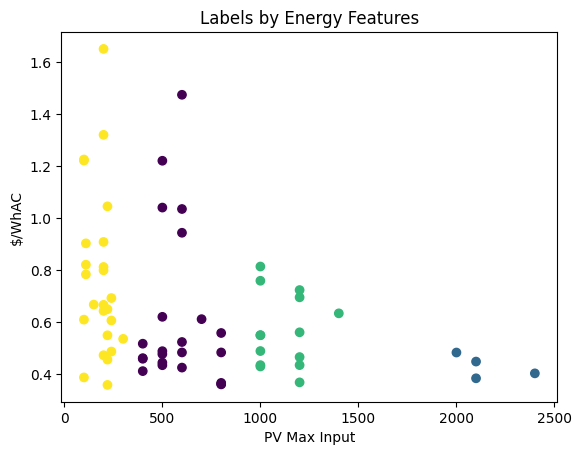

In [64]:
plt.scatter(clustered_df['Max PV Watts'],clustered_df['$/WhAC'], c=clustered_df['labels'])
plt.title('Labels by Energy Features')
plt.xlabel('PV Max Input')
plt.ylabel('$/WhAC')
plt.show() 

In [65]:


plt.scatter(clustered_df['avg retail price'],clustered_df['Battery WhAC'], c=clustered_df['labels'])
plt.title('Labels by Energy Value Features')
plt.xlabel('Retail Price')
plt.ylabel('Battery WhAC')
plt.show() 

KeyError: 'avg retail price'

## Bluetti exploration

In [116]:
# bluetti_df = clustered_df[clustered_df['Make']=='Bluetti'].drop(columns=['labels'])
# bluetti_df

In [115]:
# inertias = []

# for i in range(1,11):
#     kmeans = KMeans(n_clusters=i)
#     kmeans.fit(bluetti_df.drop(columns=['Make','Model']) )
#     inertias.append(kmeans.inertia_)

# plt.plot(range(1,11), inertias, marker='o')
# plt.title('Elbow method')
# plt.xlabel('Number of clusters')
# plt.ylabel('Inertia')
# plt.show() 

In [114]:
# kmeans = KMeans(n_clusters=3)
# kmeans.fit(bluetti_df.drop(columns=['Make','Model']))

# print(kmeans.labels_)
# bluetti_df['labels']=kmeans.labels_

In [112]:
# plt.scatter(bluetti_df['Max PV Watts'],bluetti_df['Battery WhAC'], c=bluetti_df['labels'])
# plt.title('Labels by Energy Features')
# plt.xlabel('PV Max Input')
# plt.ylabel('Battery Wh')
# plt.show() 

In [113]:
#bluetti_df

# Select Batteries

In [71]:
K = 3#best_k_silhouette  # or override manually after inspecting the plots

km_final = KMeans(n_clusters=K, random_state=10)
clustered_df["cluster"] = km_final.fit_predict(X_scaled)

print(clustered_df["cluster"].value_counts().sort_index())

cluster
0    18
1    16
2    32
Name: count, dtype: int64


In [72]:
centroids_scaled = km_final.cluster_centers_

representative_indices = []
for cluster_id in range(K):
    mask = clustered_df['cluster']==cluster_id #df_batteries["cluster"] == cluster_id
    cluster_rows = X_scaled[mask]
    original_indices = clustered_df.index[mask]
    
    dists = cdist(cluster_rows, [centroids_scaled[cluster_id]], metric="euclidean")
    closest_local = np.argmin(dists)
    representative_indices.append(original_indices[closest_local])

df_representative = clustered_df.loc[representative_indices].copy()
df_representative["cluster"] = range(K)
print(df_representative[features])

    Max PV Watts    $/WhAC
50          1200  0.559877
35           220  1.045066
49           400  0.515977


In [33]:
# # Average in original (unscaled) space so units are interpretable
# df_synthetic = (
#     clustered_df.groupby("cluster")[features]
#     .mean()
#     .reset_index()
# )

# # # Round integer-like columns if needed
# # for col in ["Cycles"]:
# #     df_synthetic[col] = df_synthetic[col].round().astype(int)

# print(df_synthetic)